In [1]:
from google.colab import files

uploaded = files.upload()

Saving population.json to population.json


In [2]:
# import
import json
import numpy as np
import matplotlib.pyplot as plt



In [4]:
with open("population.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print("Data type:", type(data).__name__)
print("Total records:", len(data))

print("\nFirst record:")
print(json.dumps(data[0], indent=2))

print("Top-level fields:",
      sorted({key for record in data for key in record}))

print("Demographic fields:",
      sorted({key for record in data
              for key in record["demographics"]}))

print("Measurement fields:",
      sorted({key for record in data
              for key in record["last_measurements"]}))

Data type: list
Total records: 152361

First record:
{
  "id": 1000000,
  "demographics": {
    "age": 88.89568973615539,
    "household_income_band": "< 35k",
    "eyecolor": "brown"
  },
  "name": "Edna Phelps",
  "last_measurements": {
    "weight": 67.12244970473641,
    "temperature": 37.45
  }
}
Top-level fields: ['demographics', 'id', 'last_measurements', 'name']
Demographic fields: ['age', 'eyecolor', 'household_income_band']
Measurement fields: ['temperature', 'weight']


In [5]:
ages = np.array([
    record["demographics"]["age"]
    for record in data
])

print(f"Mean age: {ages.mean():.4f}")
print(f"Standard deviation: {ages.std(ddof=0):.4f}")
print(f"Minimum age: {ages.min():.4f}")
print(f"Maximum age: {ages.max():.4f}")

Mean age: 39.5105
Standard deviation: 24.1527
Minimum age: 0.0007
Maximum age: 99.9915


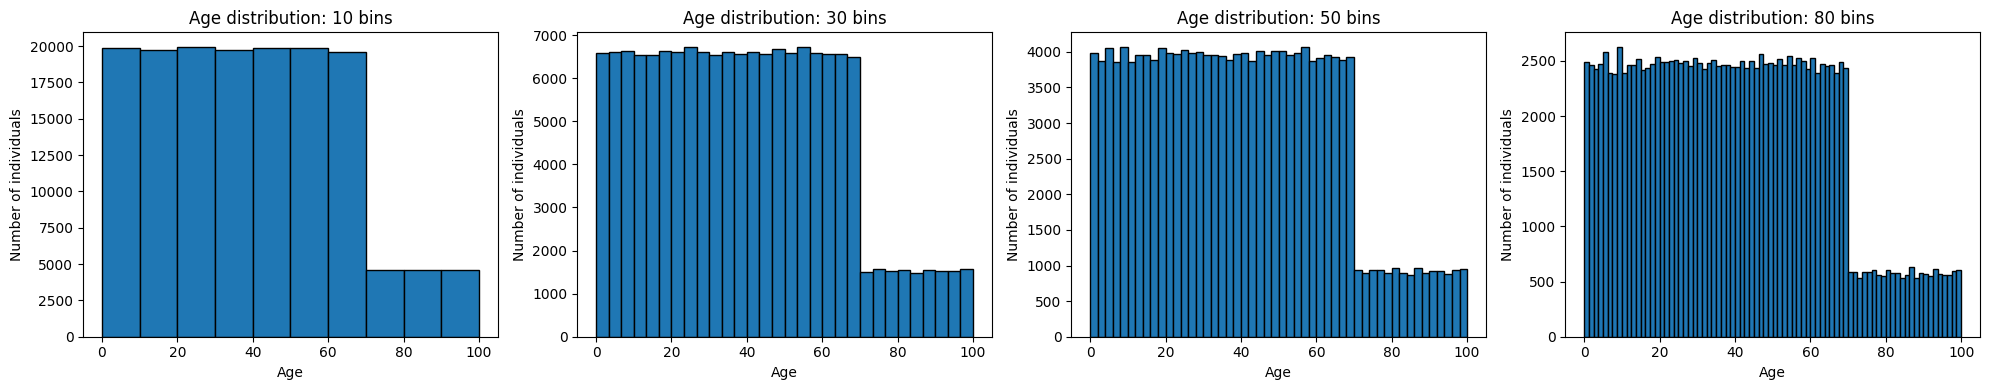

In [7]:
bin_counts = [10, 30, 50, 80]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, bins in zip(axes, bin_counts):
    ax.hist(ages, bins=bins, edgecolor="black")
    ax.set_title(f"Age distribution: {bins} bins")
    ax.set_xlabel("Age")
    ax.set_ylabel("Number of individuals")

plt.tight_layout()
plt.savefig("age_bins_comparison.png", dpi=150)
plt.show()

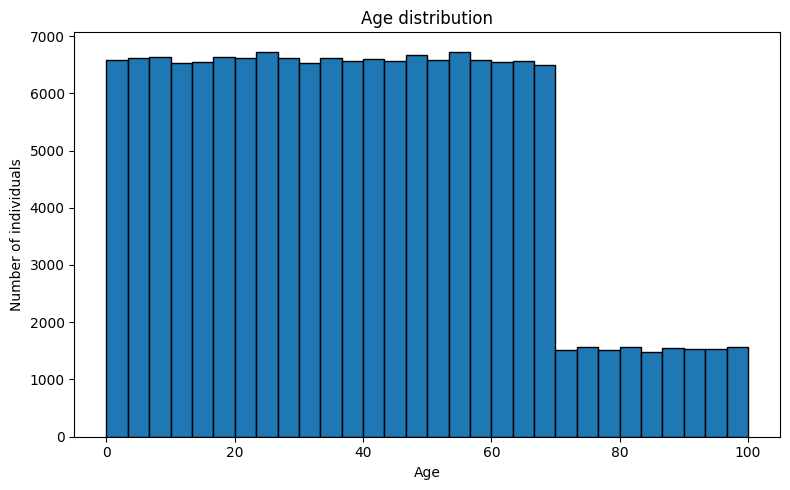

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(ages, bins=30, edgecolor="black")
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("Number of individuals")

plt.tight_layout()
plt.savefig("age_histogram.png", dpi=150)
plt.show()

In [9]:
weights = np.array([
    record["last_measurements"]["weight"]
    for record in data
])

print(f"Mean weight: {weights.mean():.4f}")
print(f"Standard deviation: {weights.std(ddof=0):.4f}")
print(f"Minimum weight: {weights.min():.4f}")
print(f"Maximum weight: {weights.max():.4f}")

Mean weight: 60.8841
Standard deviation: 18.4118
Minimum weight: 3.3821
Maximum weight: 100.4358


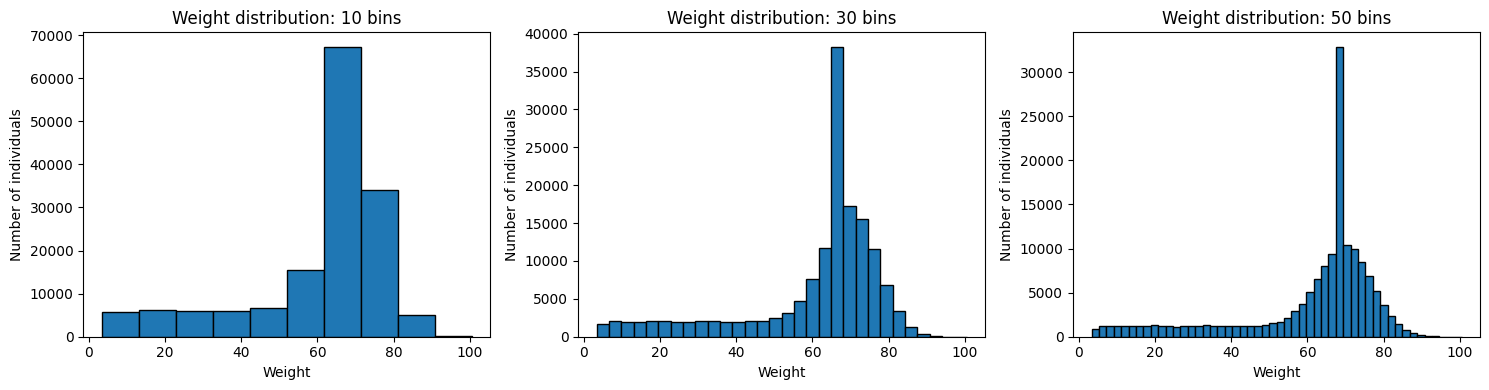

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, bins in zip(axes, bin_counts):
    ax.hist(weights, bins=bins, edgecolor="black")
    ax.set_title(f"Weight distribution: {bins} bins")
    ax.set_xlabel("Weight")
    ax.set_ylabel("Number of individuals")

plt.tight_layout()
plt.savefig("weight_bins_comparison.png", dpi=150)
plt.show()

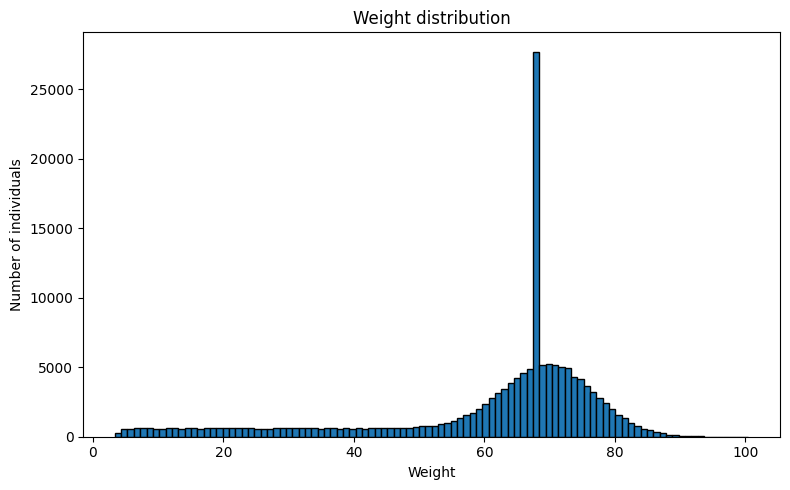

Records with weight exactly 68.0: 22613


In [12]:
plt.figure(figsize=(8, 5))

plt.hist(weights, bins=100, edgecolor="black")
plt.title("Weight distribution")
plt.xlabel("Weight")
plt.ylabel("Number of individuals")

plt.tight_layout()
plt.savefig("weight_histogram.png", dpi=150)
plt.show()

print("Records with weight exactly 68.0:",
      np.count_nonzero(weights == 68.0))

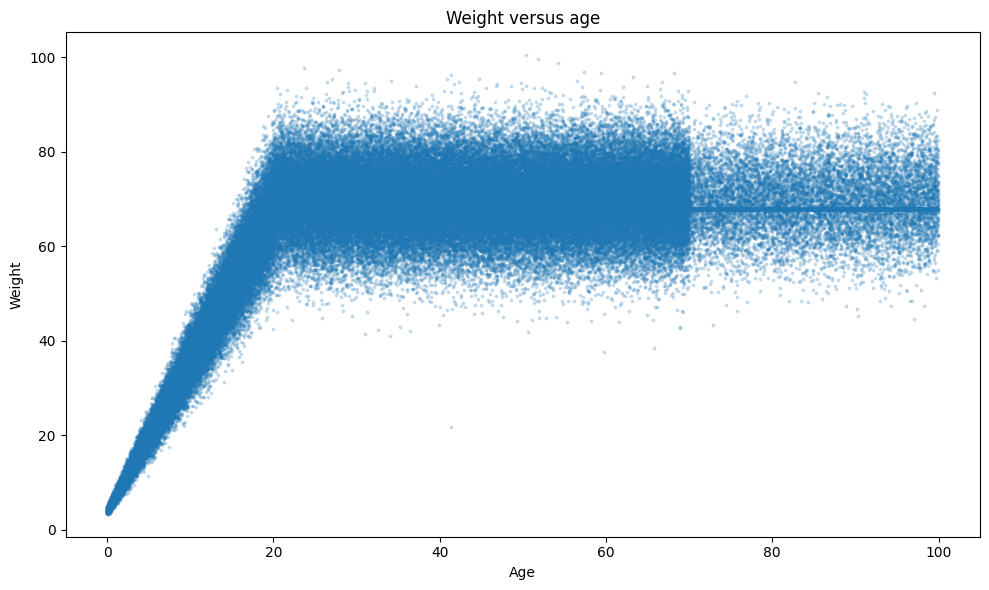

In [13]:
plt.figure(figsize=(10, 6))

plt.scatter(ages, weights, s=3, alpha=0.2)

plt.title("Weight versus age")
plt.xlabel("Age")
plt.ylabel("Weight")

plt.tight_layout()
plt.savefig("age_weight_scatter.png", dpi=150)
plt.show()

In [14]:
outliers = [
    record
    for record in data
    if record["demographics"]["age"] > 20
    and record["last_measurements"]["weight"] < 30
]

print("Number of matching records:", len(outliers))

for record in outliers:
    print(json.dumps(record, indent=2))

Number of matching records: 1
{
  "id": 1002902,
  "demographics": {
    "age": 41.3,
    "household_income_band": "< 35k",
    "eyecolor": "green"
  },
  "name": "Anthony Freeman",
  "last_measurements": {
    "weight": 21.7,
    "temperature": 35.8
  }
}


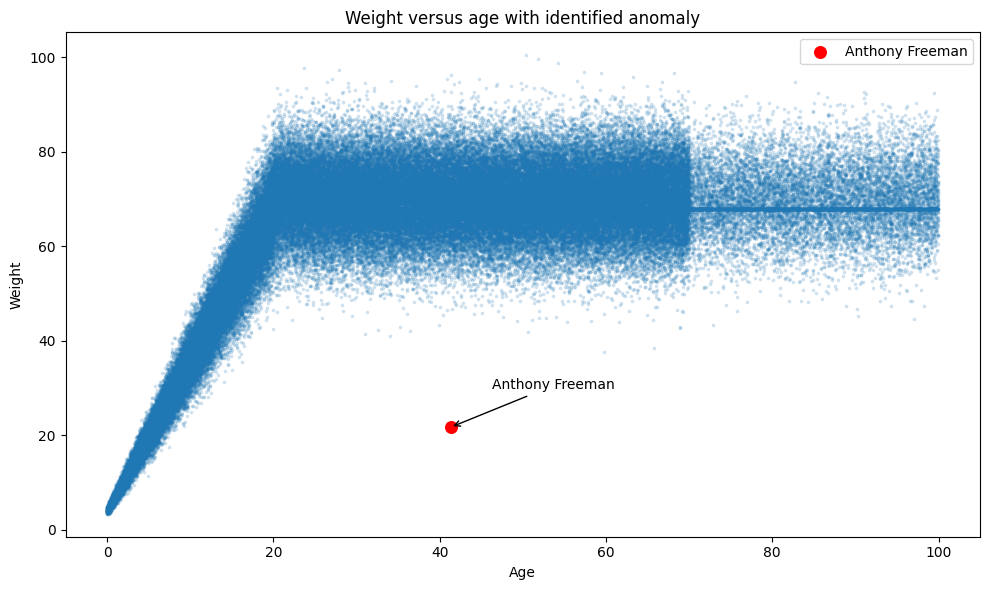

In [15]:
plt.figure(figsize=(10, 6))

plt.scatter(ages, weights, s=3, alpha=0.15)

for record in outliers:
    age = record["demographics"]["age"]
    weight = record["last_measurements"]["weight"]

    plt.scatter(
        age, weight,
        color="red",
        s=70,
        label=record["name"]
    )

    plt.annotate(
        record["name"],
        xy=(age, weight),
        xytext=(age + 5, weight + 8),
        arrowprops={"arrowstyle": "->"}
    )

plt.title("Weight versus age with identified anomaly")
plt.xlabel("Age")
plt.ylabel("Weight")
plt.legend()

plt.tight_layout()
plt.savefig("age_weight_outlier.png", dpi=150)
plt.show()